📹 **MODEL TRAINING**

✅  **Install packages**

---

*Installs every library the project needs before anything else runs.*

In [ ]:

!pip install -q transformers datasets pycocotools rouge-score \
    nltk evaluate sacrebleu pycocoevalcap Pillow kaggle torchvision

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.3/104.3 MB 10.6 MB/s eta 0:00:00


✅ **Imports & random seed**

---


*Loads all Python libraries and fixes the random seed so
results are the same every time the notebook is run*



In [2]:
import os, json, random, zipfile, urllib.request
from pathlib import Path
from PIL import Image
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torchvision import transforms
from transformers import (
    BlipProcessor,
    BlipForConditionalGeneration,
    get_linear_schedule_with_warmup,
)
import nltk
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")


Device: cpu


✅ **Mount Google Drive**

---

*Connects Google Drive so saved checkpoints and results are not lost when the Colab session ends. Saves to your own drive*


In [3]:
from google.colab import drive
drive.mount("/content/drive")

# Each user saves to their own Drive automatically
# No changes needed — this works for everyone
SAVE_DIR = Path("/content/drive/MyDrive/caption_project")
SAVE_DIR.mkdir(parents=True, exist_ok=True)
print("Checkpoints will be saved to YOUR Drive at:", SAVE_DIR)

Mounted at /content/drive
Checkpoints will be saved to YOUR Drive at: /content/drive/MyDrive/caption_project


✅ **Download COCO 2017 dataset**

---

*Downloads caption annotations and val2017 images directly from the official COCO website. Skips files already downloaded.*

In [4]:
import urllib.request

DATA_DIR = Path("/content/coco")
IMG_DIR  = DATA_DIR / "images"
ANN_DIR  = DATA_DIR / "annotations"
IMG_DIR.mkdir(parents=True, exist_ok=True)
ANN_DIR.mkdir(parents=True, exist_ok=True)

def download(url, dest):
    """Download a file only if it doesn't already exist locally."""
    if not dest.exists():
        print(f"Downloading {dest.name}…")
        urllib.request.urlretrieve(url, dest)
        print("  done.")
    else:
        print(f"  {dest.name} already exists, skipping.")

# Download caption annotations for both train and val splits
download(
    "http://images.cocodataset.org/annotations/annotations_trainval2017.zip",
    DATA_DIR / "annotations.zip"
)
with zipfile.ZipFile(DATA_DIR / "annotations.zip") as z:
    z.extractall(DATA_DIR)

# Download val2017 images (~1 GB, 5000 images)
download(
    "http://images.cocodataset.org/zips/val2017.zip",
    DATA_DIR / "val2017.zip"
)
with zipfile.ZipFile(DATA_DIR / "val2017.zip") as z:
    z.extractall(IMG_DIR)

print("Download complete.")

  done.
  done.
Download complete.


✅ **Parse captions & create splitse**

---

*Uses the exact paths confirmed from the Kaggle download
structure, then splits into 80% train / 10% val / 10% test.*

In [5]:
#Exact paths for official COCO download structure
ANN_FILE = Path("/content/coco/annotations/captions_val2017.json")
IMG_ROOT = Path("/content/coco/images/val2017")

if not ANN_FILE.exists() or not IMG_ROOT.exists():
    raise FileNotFoundError("Dataset paths not found. Check Cell 4 ran correctly.")

with open(ANN_FILE) as f:
    coco_data = json.load(f)

id2file = {img["id"]: img["file_name"] for img in coco_data["images"]}

# Build flat list of (image_path, caption) pairs
# Each image has 5 human-written captions in COCO
samples = []
for ann in coco_data["annotations"]:
    fname    = id2file[ann["image_id"]]
    img_path = IMG_ROOT / fname
    if img_path.exists():
        samples.append({
            "image_path": str(img_path),
            "caption": ann["caption"].strip()
        })

random.shuffle(samples)
n          = len(samples)
train_data = samples[:int(0.8 * n)]
val_data   = samples[int(0.8 * n):int(0.9 * n)]
test_data  = samples[int(0.9 * n):]

print(f"Total pairs  : {n}")
print(f"Train / Val / Test : {len(train_data)} / {len(val_data)} / {len(test_data)}")
print("Example:", train_data[0])


Total pairs  : 25014
Train / Val / Test : 20011 / 2501 / 2502
Example: {'image_path': '/content/coco/images/val2017/000000228144.jpg', 'caption': 'No one is in the room but there are chairs.'}


✅ **Dataset class**

---

*Converts each (image, caption) pair into model-ready tensors. Applies mild augmentation to training images only to improvegeneralization (addresses risk: poor generalization)..*

In [6]:
MAX_TARGET_LEN = 30   # COCO captions average ~10 words; 30 tokens covers most

# Mild augmentations for training set only
TRAIN_AUGMENT = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomRotation(degrees=10),
])

class COCOCaptionDataset(Dataset):
    """
    Prepares one sample at a time:
      - Opens image and converts to RGB
      - Applies augmentation if training set
      - Runs BLIP processor:
          * Resizes image to 384x384, normalizes pixel values
          * Tokenizes caption with WordPiece (~30k vocab)
          * Pads/truncates to MAX_TARGET_LEN tokens
      - Masks padding tokens with -100 so loss ignores them
    """
    def __init__(self, samples, processor, max_len=MAX_TARGET_LEN, augment=False):
        self.samples   = samples
        self.processor = processor
        self.max_len   = max_len
        self.augment   = augment

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s   = self.samples[idx]
        img = Image.open(s["image_path"]).convert("RGB")

        if self.augment:
            img = TRAIN_AUGMENT(img)

        encoding = self.processor(
            images=img,
            text=s["caption"],
            padding="max_length",
            truncation=True,
            max_length=self.max_len,
            return_tensors="pt",
        )
        item = {k: v.squeeze(0) for k, v in encoding.items()}

        labels = item["input_ids"].clone()
        labels[labels == self.processor.tokenizer.pad_token_id] = -100
        item["labels"] = labels
        return item

✅ **Load pretrained BLIP model**

---

*Downloads Salesforce/blip-image-captioning-base from Hugging Face and moves it to GPU. This is the base model we fine-tune — pretrained on 129M image-caption pairs.Fine-tuned model available at: https://huggingface.co/bajughu/group22600-image-caption-generator.*

In [7]:
MODEL_NAME = "Salesforce/blip-image-captioning-base"
MODEL_HF   = "bajughu/group22600-image-caption-generator"  # our fine-tuned version

processor = BlipProcessor.from_pretrained(MODEL_NAME)
model     = BlipForConditionalGeneration.from_pretrained(MODEL_NAME)
model.to(DEVICE)

print(f"Model       : {MODEL_NAME}")
print(f"Parameters  : {sum(p.numel() for p in model.parameters()):,}")
print(f"Vocab size  : {processor.tokenizer.vocab_size:,}")



preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

Model       : Salesforce/blip-image-captioning-base
Parameters  : 247,444,600
Vocab size  : 30,522


✅ **Create DataLoaders**

---

*Wraps each split in a DataLoader for efficient mini-batch loading. Augmentation enabled for training only. persistent_workers caches workers between epochs (faster).*

In [8]:
BATCH_SIZE = 8   # reduce to 4 if you see an OutOfMemoryError

train_ds = COCOCaptionDataset(train_data, processor, augment=True)
val_ds   = COCOCaptionDataset(val_data,   processor, augment=False)
test_ds  = COCOCaptionDataset(test_data,  processor, augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True, persistent_workers=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True, persistent_workers=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True, persistent_workers=True)

print(f"Batches — train: {len(train_loader)} | val: {len(val_loader)} | test: {len(test_loader)}")
print("Augmentation: enabled for training set only")
print("Worker caching: enabled for faster epoch loading")

Batches — train: 2502 | val: 313 | test: 313
Augmentation: enabled for training set only
Worker caching: enabled for faster epoch loading


✅ **Training loop**

---

*ine-tunes BLIP for up to 5 epochs. Now includes explicit early stopping — if validation loss does not improve for 2 consecutive epochs training stops automatically to prevent overfitting (Risk: overfitting).*

In [ ]:
EPOCHS        = 5
LR            = 5e-5   # small learning rate to avoid overwriting pretrained weights
WARMUP_STEPS  = 100    # gradually ramp up LR at the start of training
GRAD_CLIP     = 1.0    # prevents exploding gradients
PATIENCE      = 2      # early stopping — stop if val loss doesn't improve for 2 epochs

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS

# Linear warmup then linear decay over the full training run
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=WARMUP_STEPS,
    num_training_steps=total_steps,
)

best_val_loss    = float("inf")
patience_counter = 0              # tracks how many epochs without improvement
history          = {"train_loss": [], "val_loss": []}

for epoch in range(1, EPOCHS + 1):

    # ── Train phase ──
    model.train()
    train_loss = 0.0
    for step, batch in enumerate(train_loader):
        batch = {k: v.to(DEVICE) for k, v in batch.items()}

        outputs = model(**batch)   # forward pass; loss computed inside BLIP
        loss = outputs.loss

        loss.backward()            # compute gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()           # update weights
        scheduler.step()
        optimizer.zero_grad()      # clear gradients for next step

        train_loss += loss.item()
        if step % 50 == 0:
            print(f"  Epoch {epoch} | step {step}/{len(train_loader)} | loss {loss.item():.4f}")

    avg_train = train_loss / len(train_loader)

    # ── Validation phase ──
    model.eval()
    val_loss = 0.0
    with torch.no_grad():   # no gradients needed during validation
        for batch in val_loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            outputs = model(**batch)
            val_loss += outputs.loss.item()

    avg_val = val_loss / len(val_loader)
    history["train_loss"].append(avg_train)
    history["val_loss"].append(avg_val)

    print(f"\nEpoch {epoch} ── train_loss: {avg_train:.4f} | val_loss: {avg_val:.4f}")

    # ── Early stopping check ──
    if avg_val < best_val_loss:
        best_val_loss    = avg_val
        patience_counter = 0       # reset counter when model improves
        ckpt_path = SAVE_DIR / "best_model"
        model.save_pretrained(ckpt_path)
        processor.save_pretrained(ckpt_path)
        print(f"  ✓ Checkpoint saved → {ckpt_path}")
    else:
        patience_counter += 1
        print(f"  No improvement. Patience {patience_counter}/{PATIENCE}")
        if patience_counter >= PATIENCE:
            print(f"\n  Early stopping triggered after epoch {epoch}. "
                  f"Best val loss: {best_val_loss:.4f}")
            break

print("\nTraining complete.")


  Epoch 1 | step 0/2502 | loss 2.6392
  Epoch 1 | step 50/2502 | loss 2.5595
  Epoch 1 | step 100/2502 | loss 2.2286
  Epoch 1 | step 150/2502 | loss 2.7308
  Epoch 1 | step 200/2502 | loss 2.0734
  Epoch 1 | step 250/2502 | loss 2.2528
  Epoch 1 | step 300/2502 | loss 2.1165
  Epoch 1 | step 350/2502 | loss 2.0250
  Epoch 1 | step 400/2502 | loss 1.9701
  Epoch 1 | step 450/2502 | loss 2.4520
  Epoch 1 | step 500/2502 | loss 1.8763
  Epoch 1 | step 550/2502 | loss 2.5455
  Epoch 1 | step 600/2502 | loss 2.1111
  Epoch 1 | step 650/2502 | loss 1.9632
  Epoch 1 | step 700/2502 | loss 2.1577
  Epoch 1 | step 750/2502 | loss 2.6592
  Epoch 1 | step 800/2502 | loss 2.6470
  Epoch 1 | step 850/2502 | loss 1.6707
  Epoch 1 | step 900/2502 | loss 2.4883
  Epoch 1 | step 950/2502 | loss 1.9779
  Epoch 1 | step 1000/2502 | loss 2.1802
  Epoch 1 | step 1050/2502 | loss 2.1464
  Epoch 1 | step 1100/2502 | loss 1.9500
  Epoch 1 | step 1150/2502 | loss 2.5072
  Epoch 1 | step 1200/2502 | loss 2.711

In [9]:
# Run this to restore lost variables
EPOCHS = 2   # number of epochs you completed

# Manually enter your results from the training output
history = {
    "train_loss": [2.0695, 1.5610],
    "val_loss":   [1.9909, 1.9545]
}

print("Variables restored. Ready to plot.")

Variables restored. Ready to plot.


✅ **Plot loss curves**

---

*Shows how training and validation loss changed each epochso you can spot overfitting or underfitting at a glance.*

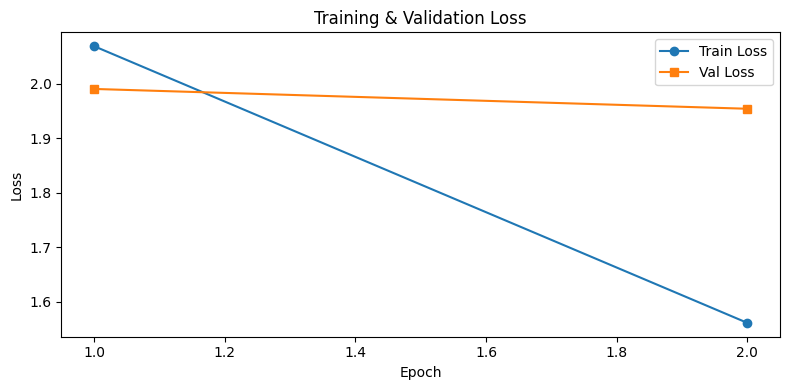

In [10]:
import matplotlib.pyplot as plt

epochs_range = range(1, EPOCHS + 1)
plt.figure(figsize=(8, 4))
plt.plot(epochs_range, history["train_loss"], label="Train Loss", marker="o")
plt.plot(epochs_range, history["val_loss"],   label="Val Loss",   marker="s")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend(); plt.tight_layout()
plt.savefig(SAVE_DIR / "loss_curve.png", dpi=150)
plt.show()




---



---

